## CSCI 347 Project 01: Exploratory Data Analysis
Authors: John Nelson, Lucas Jones, Henry Stickling


Febuary 16th, 2026

## Dataset

https://archive.ics.uci.edu/dataset/149/statlog+vehicle+silhouettes (Link to repo site)

In [ ]:
from ucimlrepo import fetch_ucirepo 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
  
# fetch dataset 
statlog_vehicle_silhouettes = fetch_ucirepo(id=149) 
  
# data (as pandas dataframes) 
X = statlog_vehicle_silhouettes.data.features 
y = statlog_vehicle_silhouettes.data.targets 
  
# metadata 
#print(statlog_vehicle_silhouettes.metadata) 
  
# variable information 
#print(statlog_vehicle_silhouettes.variables) 

In [ ]:
df = pd.concat([X, y], axis=1)   # combine datasets to get the categorical variable
df

,COMPACTNESS,CIRCULARITY,DISTANCE CIRCULARITY,RADIUS RATIO,PR.AXIS ASPECT RATIO,MAX.LENGTH ASPECT RATIO,SCATTER RATIO,ELONGATEDNESS,PR.AXIS RECTANGULARITY,MAX.LENGTH RECTANGULARITY,SCALED VARIANCE ALONG MAJOR AXIS,SCALED VARIANCE ALONG MINOR AXIS,SCALED RADIUS OF GYRATION,SKEWNESS ABOUT MAJOR AXIS,SKEWNESS ABOUT MINOR AXIS,KURTOSIS ABOUT MINOR AXIS,KURTOSIS ABOUT MAJOR AXIS,HOLLOWS RATIO,class
0,95.0,48,83,178,72,10,162,42,20,159,176,379,184,70,6,16,187,197,van
1,91.0,41,84,141,57,9,149,45,19,143,170,330,158,72,9,14,189,199,van
2,104.0,50,106,209,66,10,207,32,23,158,223,635,220,73,14,9,188,196,saab
3,93.0,41,82,159,63,9,144,46,19,143,160,309,127,63,6,10,199,207,van
4,85.0,44,70,205,103,52,149,45,19,144,241,325,188,127,9,11,180,183,bus
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
841,93.0,39,87,183,64,8,169,40,20,134,200,422,149,72,7,25,188,195,saab
842,89.0,46,84,163,66,11,159,43,20,159,173,368,176,72,1,20,186,197,van
843,106.0,54,101,222,67,12,222,30,25,173,228,721,200,70,3,4,187,201,saab
844,86.0,36,78,146,58,7,135,50,18,124,155,270,148,66,0,25,190,195,saab


## Problem 1

**a) What is the data used for (explain this in a well-written paragraph)? [5 points]**

Answer: The current purpose of this data set is to train machine learning models to classify the silhouette of a vehicle, using a set of features derived from the dataset. The data was initially gathered at the Turner Institution in 1986 by JP Siebert. The original purpose was to find a method to distinguish 3D objects within a 2D image. This object recognition system was succesful at discriminating between silhouettes of different vehicles.

**b) Who (or what organization) uploaded the data? [1 point]**


Answer: The creators of this dataset are Pete Mowforth and Barry Shepherd.

**c) How many attributes and how many entries are included in the data?**
    
    a. How many numerical attributes? [1 point]
    b. How many categorical attributes? [1 point]
    c. For the categorical attributes, would you suggest integer encoding (label encoding) or
    one-hot encoding? And why? Answer this for each categorical attribute. [3 points]


    a. The dataset has 18 numerical attributes.
    b. The dataset has one categorical attribute.
    c. For the categorical attribute, I would suggest Integer/Label encoding. This is because the categorical attribute in this data set is vehicle class/type, and there are 4 possibilities. Integer encoding will not add collomns to the dataset, keeping the dataframe easy to work with. 

**d) Missing values:**
    
    a. Are there missing values in this dataset? [1 point]
    b. If so, for each attribute, what is the proportion of the data that is missing? [4 points]
    c. What is the proportion of the missing data overall? (You can use the plots to summarize this data and explain each answer). [1 point]

    a. There is a missing data point in the compactness column, there is only 1.
    b. 1/846
    c. 1/(846(19))


**e) What is the most interesting thing about this dataset to you? Explain this in a well-written paragraph. [6 points]**

Answer: The most interesting thing about this data set is that it turns raw images of vehicles into geometry. It demonstrates how vehicles can be classified by using only the shape descriptions of each of the vehicles.

**f) Out of all the attributes in this dataset, what do you think are the most descriptive attributes? (before doing any data analysis)? [5 points]**

Answer: Of all of the attributes in this dataset, the most descriptive attributes are probably compactness, circularity, elongatedness, scatter ratio, and hollows ratio.

## Problem 2

**a) Write a function that computes the multi-dimensional mean of the numerical attributes. You should return the answer as a 2D NumPy array. [5 points]**

In [ ]:
def MDmean_calc(df):
    means = df.mean().values
    return means.reshape(1, -1)

**b) A function to calculate sample variance of a given attribute. [5 points]**

In [ ]:
def variance_calc(col):
    col_mean = col.mean()
    n = len(col)
    variance = np.sum((col - col_mean)**2)/ (n-1)
    return variance

**c) A function to calculate sample covariance between two given attributes. [5 points]**

In [ ]:
def covariance_calc(col1, col2):
    col1 = np.array(col1, dtype=float)
    col2 = np.array(col2, dtype=float)

    n = len(col1)
    col1_mean = np.mean(col1)
    col2_mean = np.mean(col2)

    covariance = np.sum((col1 - col1_mean) * (col2 - col2_mean)) / (n - 1)
    return covariance

**d) A function that calculates the covariance matrix. (You can use the functions that you have created in b and c). [5 points]**

In [ ]:
def covariance_matrix(df):
    n_features = df.shape[1]
    cov_matrix = np.zeros((n_features, n_features))

    for i in range(n_features):
        for j in range(n_features):
            cov_matrix[i, j] = covariance_calc(df.iloc[:, i], df.iloc[:, j])
                
    return cov_matrix

**e) A function to calculate the correlation coefficient between two attributes. [5 points]**

In [ ]:
def correlation_coef_calc(col1, col2):
    n = len(col1)
    mean_col1 = sum(col1) / n
    mean_col2 = sum(col2) / n

    num = sum((col1[i] - mean_col1) * (col2[i] - mean_col2) for i in range (n))
    SScol1 = sum((col1[i] - mean_col1)**2 for i in range(n))
    SScol2 = sum((col2[i] - mean_col2)**2 for i in range(n))
    denom = (SScol1**0.5) * (SScol2**0.5)

    return num / denom

**f) A function that normalizes the attributes in a 2D NumPy array using z-score normalization. [5 points]**

In [ ]:
def Zscore_Normalizer(df): 
    numeric_df = df.select_dtypes(include=[int, float]).copy()
    normalized_df = numeric_df.copy()

    for col in numeric_df.columns:
        mean_val = numeric_df[col].mean()
        n = len(numeric_df[col])
        std_val = ((sum((x - mean_val)**2 for x in numeric_df[col])) / n)**0.5

        normalized_df[col] = [(x - mean_val)/std_val for x in numeric_df[col]]

    return normalized_df

**g) A function that normalizes the attributes in a 2D NumPy array using range normalization. [5 points]**

In [ ]:
def normalize(array_2D):
    normalizedArray = np.zeros(((len(array_2D)),(len(array_2D[0]))), dtype=float)
    for j in range(len(array_2D)):
        for i in range(len(array_2D[0])):
            maximum = array_2D.max(axis=0)
            minimum = array_2D.min(axis=0)
            normalizedValue = (array_2D[j,i] - minimum[i]) / (maximum[i] - minimum[i])
            normalizedArray[j,i] = round(normalizedValue, 4)
    return normalizedArray

def range_normalize_df(df):
    return (df - df.min()) / (df.max() - df.min())

**h) A function that will compute the covariance matrix of a dataset. [5 points]**

In [ ]:
def covariance_matrix(df):
    n_features = df.shape[1]
    cov_matrix = np.zeros((n_features, n_features))

    for i in range(n_features):
        for j in range(n_features):
            if i == j:
                cov_matrix[i, j] = variance_calc(df.iloc[:, i])
            else:
                cov_matrix[i, j] = covariance_calc(df.iloc[:, i], df.iloc[:, j])
                
    return cov_matrix

**i) A function that will label-encode a 2D categorical data array that is passed as an input. The function can expect that the user is passing a 2D array with attributes that are only categorical, and the function should output a new data matrix with the converted label-encoded (integer-encoded) data. [5 points]**

In [ ]:
def labelEncode(data_array):
    data = np.array(data_array)
    rows, columns = data.shape
    encoded_matrix = np.zeros((rows, columns), dtype=int)
    
    for j in range(columns):
        column = data[:, j]
        unique_categories = sorted(list(set(column)))
        mapping = {category: i for i, category in enumerate(unique_categories)}
        for i in range(rows):
            encoded_matrix[i, j] = mapping[column[i]]
    return encoded_matrix

## Problem 3

**a) First, calculate the multi-dimensional mean and covariance matrix of the numerical portion of the data. [2 points]**

In [ ]:
numerical_only = df.drop('class', axis = 1)
numerical_only = numerical_only.dropna()
my_covm = covariance_matrix(numerical_only)
my_multi_mean = MDmean_calc(numerical_only)

print("Covariance Matrix:\n", my_covm, "\n\n", "Multi-dimensional Mean:\n", my_multi_mean)

Covariance Matrix:
 [[ 6.78395019e+01  3.53097970e+01  1.03105018e+02  1.90639432e+02
   5.97769147e+00  5.64286155e+00  2.22878625e+02 -5.07821027e+01
   1.73876707e+01  8.10717771e+01  1.97847996e+02  1.19278810e+03
   1.57433498e+02 -1.56118049e+01  9.47861269e+00  1.14958496e+01
   1.50493228e+01  2.23555105e+01]
 [ 3.53097970e+01  3.80191901e+01  7.76963698e+01  1.29083857e+02
   7.41290418e+00  7.00664068e+00  1.76613166e+02 -4.00000351e+01
   1.37310553e+01  8.63762514e+01  1.56796782e+02  9.30257582e+02
   1.87672168e+02  2.70849996e+00  4.50565355e+00 -7.86842031e-01
  -4.18802266e+00  1.86519953e+00]
 [ 1.03105018e+02  7.76963698e+01  2.48937974e+02  4.08163451e+02
   2.02415169e+01  1.91754564e+01  4.76198843e+02 -1.12539731e+02
   3.66398006e+01  1.77298592e+02  4.28530228e+02  2.48174832e+03
   3.62195475e+02 -2.73920245e+01  9.04181132e+00  3.73735733e+01
   1.45222272e+01  3.94925489e+01]
 [ 1.90639432e+02  1.29083857e+02  4.08163451e+02  1.12064268e+03
   1.75496964e+02

**b) Then, convert all the categorical data attributes to numerical attributes using label encoding or
one-hot encoding. [5 points]**

In [ ]:
vehicle_col = df.iloc[:, 18]
vehicle_col = vehicle_col.map({
    "van": 1, "bus": 2, "saab": 3, "opel": 4 })

vehicle_col
df["class"] = vehicle_col
df

,COMPACTNESS,CIRCULARITY,DISTANCE CIRCULARITY,RADIUS RATIO,PR.AXIS ASPECT RATIO,MAX.LENGTH ASPECT RATIO,SCATTER RATIO,ELONGATEDNESS,PR.AXIS RECTANGULARITY,MAX.LENGTH RECTANGULARITY,SCALED VARIANCE ALONG MAJOR AXIS,SCALED VARIANCE ALONG MINOR AXIS,SCALED RADIUS OF GYRATION,SKEWNESS ABOUT MAJOR AXIS,SKEWNESS ABOUT MINOR AXIS,KURTOSIS ABOUT MINOR AXIS,KURTOSIS ABOUT MAJOR AXIS,HOLLOWS RATIO,class
0,95.0,48,83,178,72,10,162,42,20,159,176,379,184,70,6,16,187,197,1.0
1,91.0,41,84,141,57,9,149,45,19,143,170,330,158,72,9,14,189,199,1.0
2,104.0,50,106,209,66,10,207,32,23,158,223,635,220,73,14,9,188,196,3.0
3,93.0,41,82,159,63,9,144,46,19,143,160,309,127,63,6,10,199,207,1.0
4,85.0,44,70,205,103,52,149,45,19,144,241,325,188,127,9,11,180,183,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
841,93.0,39,87,183,64,8,169,40,20,134,200,422,149,72,7,25,188,195,3.0
842,89.0,46,84,163,66,11,159,43,20,159,173,368,176,72,1,20,186,197,1.0
843,106.0,54,101,222,67,12,222,30,25,173,228,721,200,70,3,4,187,201,3.0
844,86.0,36,78,146,58,7,135,50,18,124,155,270,148,66,0,25,190,195,3.0


The label encoding switches ["van", "bus", "saab", "opel"] values to [1, 2, 3, 4] respectively. 

**c) If your data has missing values, fill these values with attribute mean. [3 points]**

In [ ]:
df = df.fillna(df.mean())

**d) Recalculate the multi-dimensional mean of the data matrix after the transformation (categorical attributes are now numerical). [2 points]**

In [ ]:
new_md_mean = MDmean_calc(df)
print("The new multi-dimensional mean:\n", new_md_mean)

The new multi-dimensional mean:
 [[ 93.67100592  44.93735225  82.04491726 168.79196217  61.8427896
    8.6465721  168.65484634  41.07801418  20.60638298 147.87234043
  188.55200946 439.6607565  175.02955083  72.5248227    6.45508274
   12.58392435 188.71867612 195.62765957   2.52307692]]


**e) What is the new covariance matrix of the data (categorical attributes are now numerical). [3 points]**

In [ ]:
new_covm = covariance_matrix(df)
print("The new covariance matrix:\n", new_covm)

The new covariance matrix:
 [[ 6.77592185e+01  3.52680102e+01  1.02983001e+02  1.90413823e+02
   5.97061728e+00  5.63618361e+00  2.22614864e+02 -5.07220055e+01
   1.73670936e+01  8.09758342e+01  1.97613857e+02  1.19137652e+03
   1.57247186e+02 -1.55933294e+01  9.46739540e+00  1.14822450e+01
   1.50315129e+01  2.23290543e+01  2.35670460e+00]
 [ 3.52680102e+01  4.15664848e+01  7.46004504e+01  1.22681626e+02
   1.63522696e+01  1.11967672e+01  1.65792552e+02 -3.20637459e+01
   1.49800453e+01  7.79316379e+01  1.52595570e+02  9.12803574e+02
   2.02192386e+02  6.12877586e+00  8.77647265e+00 -1.21544617e+00
  -1.52555150e+01  2.14824374e+00  1.68697315e+00]
 [ 1.02983001e+02  7.46004504e+01  2.51155377e+02  4.12906397e+02
   1.27348805e+01  1.56419293e+01  4.84509013e+02 -1.19003508e+02
   3.55384112e+01  1.84064913e+02  4.31381093e+02  2.49248626e+03
   3.49438908e+02 -3.02224181e+01  5.45527439e+00  3.76885336e+01
   2.37641305e+01  3.92072768e+01  7.26042786e+00]
 [ 1.90413823e+02  1.226816

**f) Choose 4 pairs of numerical attributes that you think might be related. Create scatter plots for these 4 pairs of attributes, along with the description and analysis of why these pairs of attributes are related and how the scatter plot does or does not support your intuition. [5 points]**

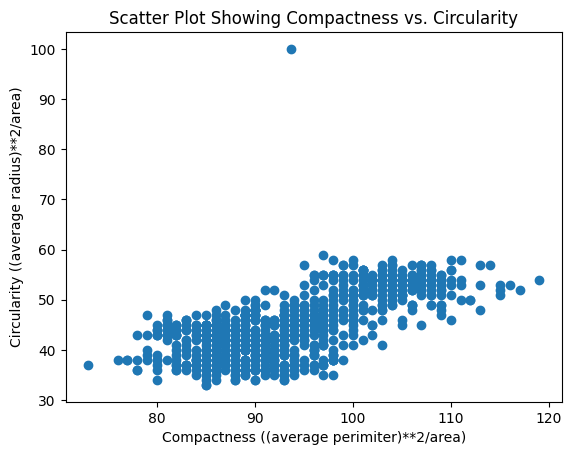

In [ ]:
# Plot 1, compactness and circularity
plt.scatter(df.iloc[:, 0], df.iloc[:, 1])
plt.xlabel("Compactness ((average perimiter)**2/area)")
plt.ylabel("Circularity ((average radius)**2/area)")
plt.title("Scatter Plot Showing Compactness vs. Circularity")
plt.show()

We chose compactness ((average perimiter)**2/area) and circularity ((average radius)**2/area) as they are both aspects of the shape of the vehicle. Since the parameters for each calculation are similar, We assumed they would share a consistent relationship between eachother. The scatter plot shows a moderate positive relationship between compactness and circularity. As compactness increases, circularity also tends to increase. The relationship is not perfectly linear and there is a clear outlier, however, the scatter plot still supports the intuition that compactness and circularity are related.

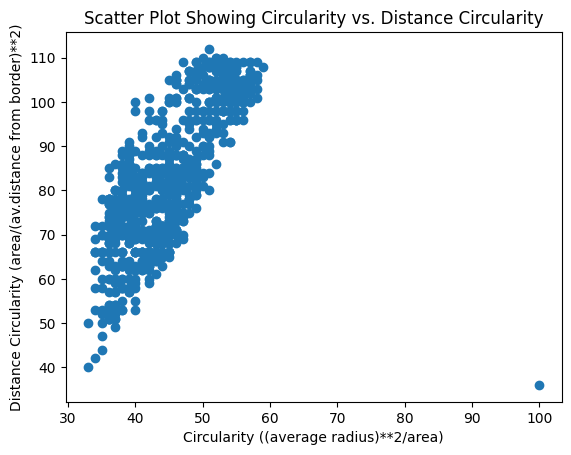

In [ ]:
# Plot 2, Circularity vs Distance Circularity
plt.scatter(df.iloc[:, 1], df.iloc[:, 2])
plt.ylabel("Distance Circularity (area/(av.distance from border)**2)")
plt.xlabel("Circularity ((average radius)**2/area)")
plt.title("Scatter Plot Showing Circularity vs. Distance Circularity")
plt.show()

We chose circularity ((average radius)**2/area) and distance circularity (area/(av.distance from border)**2) as they both have to do with the curvature of the vehicle. Since they are both measures of 'roundness', a positive relationship was expected. The scatter plot shows a strong positive linear relationship. As circularity increases, distance circularity also increases in an upward trend. The scatter plot supports the idea that circularity and distance circularity are closely related features. 

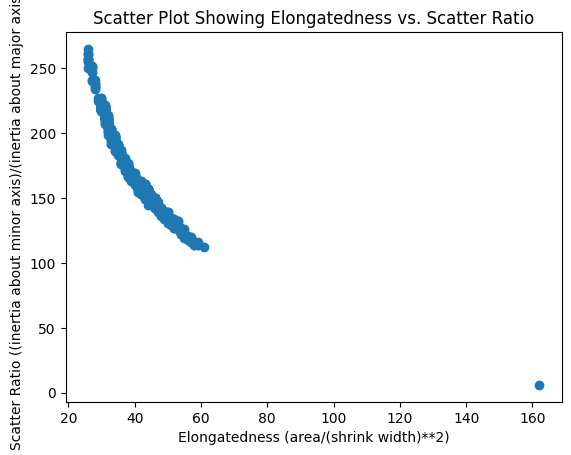

In [ ]:
# Plot 3 Elongatedness vs Scatter Ratio
plt.scatter(df.iloc[:, 7], df.iloc[:, 6])
plt.ylabel("Scatter Ratio ((inertia about minor axis)/(inertia about major axis))")
plt.xlabel("Elongatedness (area/(shrink width)**2)")
plt.title("Scatter Plot Showing Elongatedness vs. Scatter Ratio")
plt.show()

We chose elongatedness (area/(shrink width)**2) and scatter ratio ((inertia about minor axis)/(inertia about major axis)), as their values appeared to be similar. The scatter plot shows a strong negative relationship between elongatedness and scatter ratio. As elongatedness increases, the scatter ratio decreases in a curved pattern. This indicates that more elongated vehicles usually have a lower ratio of inertia about the minor axis relative to the major axis. The scatter plot supports the idea that elongatedness and scatter ratio are closely related measures.

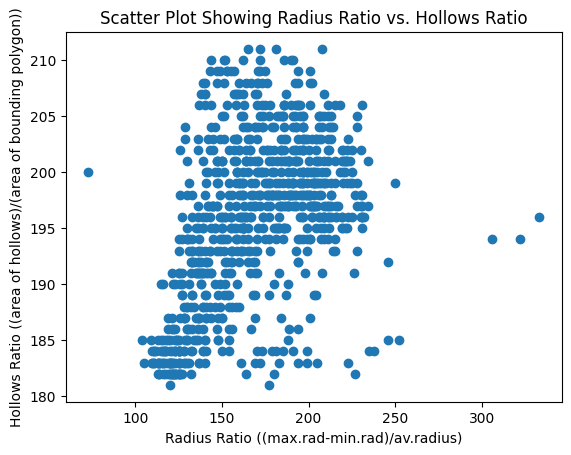

In [ ]:
# Plot 4 Radius Ratio vs. Hollows Ratio
plt.scatter(df.iloc[:, 3], df.iloc[:, 17])
plt.ylabel("Hollows Ratio ((area of hollows)/(area of bounding polygon))")
plt.xlabel("Radius Ratio ((max.rad-min.rad)/av.radius)")
plt.title("Scatter Plot Showing Radius Ratio vs. Hollows Ratio")
plt.show()

We used radius ratio ((max.rad-min.rad)/av.radius) and hollows ratio ((area of hollows)/(area of bounding polygon)) as they both have to do with the shape of the vehicle, they do not seem like they would have a strong relationship, however, we were curious. The scatter plot shows a weak positive relationship. As the radius ratio increases, the hollows ratio tends to increase slightly if at all. Overall, this scatter plot provides limited evidence of a relationship between radius ratio and the hollows ratio.

**g) Which range-normalized numerical attributes have the largest estimated covariance? What is the covariance? Create a scatter plot of these range-normalized attributes. [3 points]**

In [ ]:
range_norm = range_normalize_df(df)
range_covm = covariance_matrix(range_norm)
n = range_norm.shape[1]
max_cov = -np.inf
max_pair = (None, None)

for i in range(n):
    for j in range(i + 1, n):
        cov = range_covm[i, j]
        if cov > max_cov:
            max_cov = cov
            max_pair = (range_norm.columns[i], range_norm.columns[j])

print("Largest Estimated Covariance:", max_cov)
print("Between attributes:", max_pair)

Largest Estimated Covariance: 0.03932358736964875
Between attributes: ('DISTANCE CIRCULARITY', 'SCALED VARIANCE ALONG MINOR AXIS')


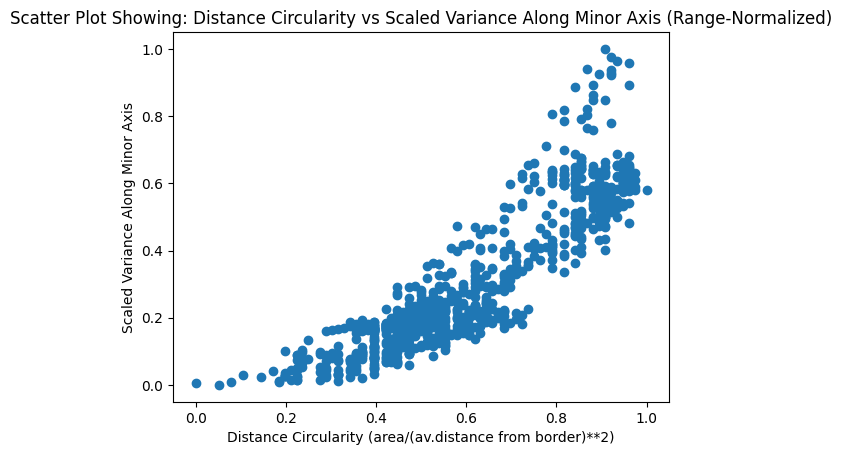

In [ ]:
plt.scatter(range_norm[max_pair[0]], range_norm[max_pair[1]])
plt.xlabel("Distance Circularity (area/(av.distance from border)**2)")
plt.ylabel("Scaled Variance Along Minor Axis")
plt.title("Scatter Plot Showing: Distance Circularity vs Scaled Variance Along Minor Axis (Range-Normalized)")
plt.show()

**h) Which z-score normalized numerical attributes have the largest estimated correlation coefficient between them? What is that value? Create a scatter plot for these two z-score normalized attributes. [3 points]**

In [ ]:
Z_normalized = Zscore_Normalizer(df)

n_cols = Z_normalized.shape[1]
max_corr = -1
max_pair = (None, None)

for i in range(n_cols):
    for j in range(i + 1, n_cols):
        corr = correlation_coef_calc(Z_normalized.iloc[:,i], Z_normalized.iloc[:, j])
        if corr > max_corr:
            max_corr = corr
            max_pair = (Z_normalized.columns[i], Z_normalized.columns[j])

print("Largest Estimated Correlation:", max_corr, "between attributes:", max_pair)

Largest Estimated Correlation: 0.9894129478622536 between attributes: ('SCATTER RATIO', 'SCALED VARIANCE ALONG MINOR AXIS')


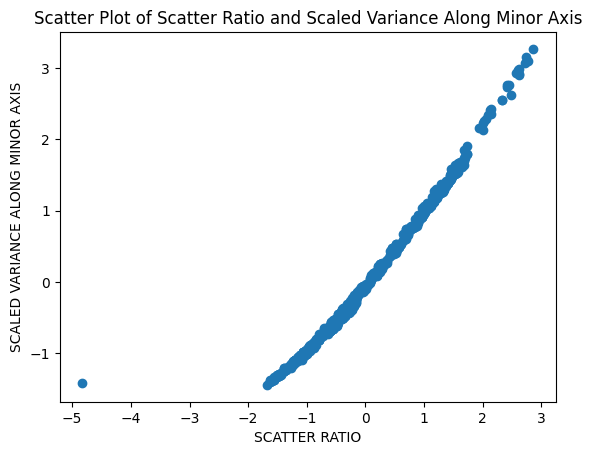

In [ ]:
plt.scatter(Z_normalized[max_pair[0]], Z_normalized[max_pair[1]])
plt.xlabel(max_pair[0])
plt.ylabel(max_pair[1])
plt.title("Scatter Plot of Scatter Ratio and Scaled Variance Along Minor Axis")
plt.show()

**i) Which z-score normalized numerical attributes have the smallest estimated correlation coefficient between them? What is that value? Create a scatter plot for these two z-score normalized attributes. [3 points]**

In [ ]:
min_corr = 1
min_pair = (None, None)

for i in range(n_cols):
    for j in range(i + 1, n_cols):
        corr = correlation_coef_calc(Z_normalized.iloc[:,i], Z_normalized.iloc[:, j])
        if corr < min_corr:
            min_corr = corr
            min_pair = (Z_normalized.columns[i], Z_normalized.columns[j])

print("Smallest Estimated Correlation:", min_corr, "between attributes:", min_pair)

Smallest Estimated Correlation: -0.92526579532912 between attributes: ('SCATTER RATIO', 'ELONGATEDNESS')


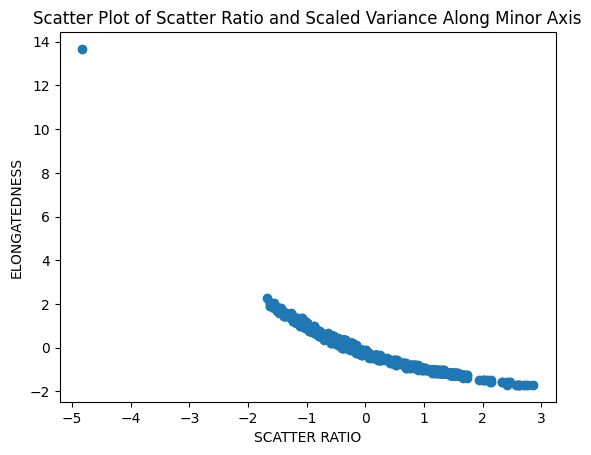

In [ ]:

plt.scatter(Z_normalized[min_pair[0]], Z_normalized[min_pair[1]])
plt.xlabel(min_pair[0])
plt.ylabel(min_pair[1])
plt.title("Scatter Plot of Scatter Ratio and Scaled Variance Along Minor Axis")
plt.show()


**j) How many pairs of numerical features have a correlation greater than or equal to 0.5? [3 points]**

In [ ]:
corr_count = 0

for i in range(n_cols):
    for j in range(i + 1, n_cols):
        corr = correlation_coef_calc(Z_normalized.iloc[:, i], Z_normalized.iloc[:, j])
        if abs(corr) >= 0.5:
            corr_count += 1

print(corr_count, "pairs greater than or equal to 0.5 correlation")

60 pairs greater than or equal to 0.5 correlation


**k) How many pairs of numerical features have negative estimated covariance? [3 points]**

In [ ]:
my_covm = covariance_matrix(numerical_only)

negativeCovarianceCount = 0
columns = my_covm.shape[0]
for i in range(columns):
    for j in range(i + 1, columns): 
        if my_covm[i, j] < 0:
            negativeCovarianceCount += 1
print(f"Pairs with negative estimated covariance: {negativeCovarianceCount}")

Pairs with negative estimated covariance: 37


**l) Calculate the total variance of the data. [2 points]**

In [ ]:
my_covm = covariance_matrix(numerical_only)

variances = np.diag(my_covm)
total_estimated_variance = np.sum(variances)
print(f"Total variance of the data: {total_estimated_variance:.4f}")

Total variance of the data: 36496.7474


**m) What is the ratio of the total variance of the data restricted to the five features with the highest estimated variance to the total estimated variance of the data? [2 points]**

In [ ]:
my_covm = covariance_matrix(numerical_only)

sorted_variances = np.sort(variances)[::-1]
top_5_variance_sum = np.sum(sorted_variances[:5])
variance_ratio = top_5_variance_sum / total_estimated_variance
print(f"Ratio (Top5 Variance/total Variance): {variance_ratio:.4f}")

Ratio (Top5 Variance/total Variance): 0.9734
